<a href="https://colab.research.google.com/github/IsabelleCoughlin/375/blob/main/NNProj3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Denoising Pulsar Data with NN

We are training an LSTM and Autoencoder model on two datasets with different types of noise. We are training both models exclusively on simulated data and predicting a smoothed signal for the real pulsar data stored in .FITS files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

os.chdir('/content/drive/MyDrive/Pulsar')


Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Creating simulated data with gaussian pulses

In [12]:
def gaussian(size, std):
    x = np.arange(size) - size // 2
    return np.exp(-x**2 / (2 * std**2))

def generate_clean_signal(num_bins=1000, period=100, pulse_width=15):
    signal = np.zeros(num_bins)
    pulse = gaussian(pulse_width * 2, std=pulse_width / 3)
    for i in range(0, num_bins, period):
        if i + pulse_width * 2 <= num_bins:
            signal[i:i + pulse_width * 2] += pulse
    return signal / np.max(signal)  # normalize

# Creating Simulated Datasets

0


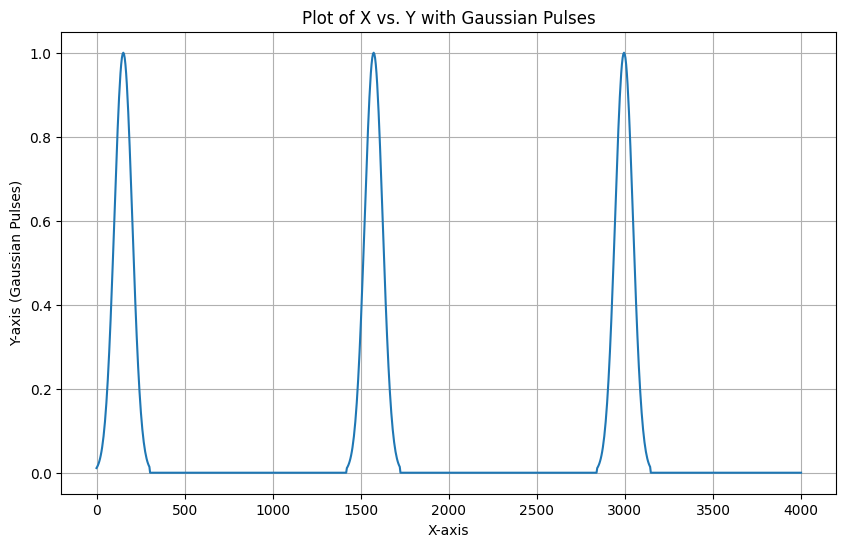

In [163]:
num_samples = 100 # 100 samples for LSTM but 10,000 for autoencoder
samples = []

# Generate x and y values
num_points = 1000
x_values = np.linspace(0, 4000, num_points)

# generate samples
for j in range(0, num_samples):
  signal = generate_clean_signal(num_bins=num_points, period=np.random.randint(30, 800), pulse_width=np.random.randint(1, 50))
  samples.append((x_values, signal))
np.save('./signal_13.npy', samples)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x_values, signal)
plt.xlabel("X-axis")
plt.ylabel("Y-axis (Gaussian Pulses)")
plt.title("Plot of X vs. Y with Gaussian Pulses")
plt.grid(True)
plt.show()


# Adding Noise to Data

The following noise, for which we've labelled "Single Directional Noise" is a combination of Additive white Gaussian noise (AWGN), Impulse noise (spikes).

In [1]:
def add_noise_to_signal(clean_signal, noise_level, spike_prob=0.01):
  # Gaussian noise
  noisy = clean_signal + np.random.normal(0, noise_level, size=clean_signal.shape)

  # Impulse spikes
  spikes = np.random.rand(*clean_signal.shape) < spike_prob
  noisy[spikes] += np.random.uniform(0.2, 1.0, size=np.sum(spikes))

  # Normalize
  noisy = np.clip(noisy, 0, None)
  noisy /= np.max(noisy)
  return noisy

Single Directional Noise

In [166]:
# Sample configuration
num_samples_visualize = 10

# Load data
data = np.load('./signal_13.npy')
x_val, y_val = data[:,0], data[:,1]

# Add noise to data
noisy_samples = []
for i in range(0, len(x_val)):
  if i % 100 == 0:
    print(i)
  pure = np.array(y_val[i])

  # More data-looking noise with positive guassian and spikes
  noise = np.random.random()
  signal = add_noise_to_signal(pure, noise)
  noisy_samples.append([x_val[i], signal])

# Save to file
np.save('./signal_13_noisy.npy', noisy_samples)


0


Dual Directional Noise - Guassian noise scaled by a random factor

In [167]:
num_samples_visualize = 10
# Load data
data = np.load('./signal_13.npy')
x_val, y_val = data[:,0], data[:,1]

# Add noise to data
noisy_samples = []
for i in range(0, len(x_val)):
  pure = np.array(y_val[i])
  # Original way to add noise
  noise = np.random.normal(0, 1, pure.shape)
  noise_factor = np.random.rand()
  signal = pure + noise_factor * noise
  noisy_samples.append([x_val[i], signal])

# Save to file
np.save('./signal_13_noisy.npy', noisy_samples)


0


Checking on datasets and visualizing

In [168]:
noisy_samples = np.load('./signal_13_noisy.npy')
clean_samples = np.load('./signal_13.npy')

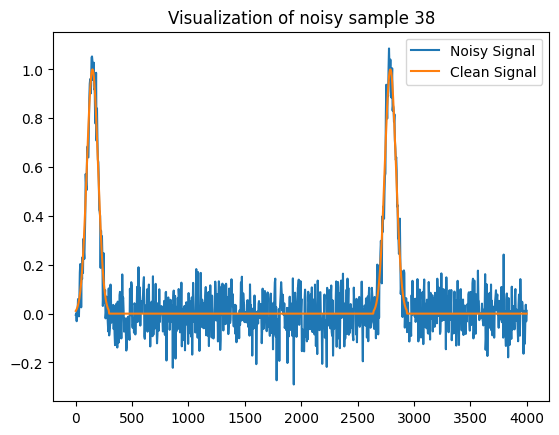

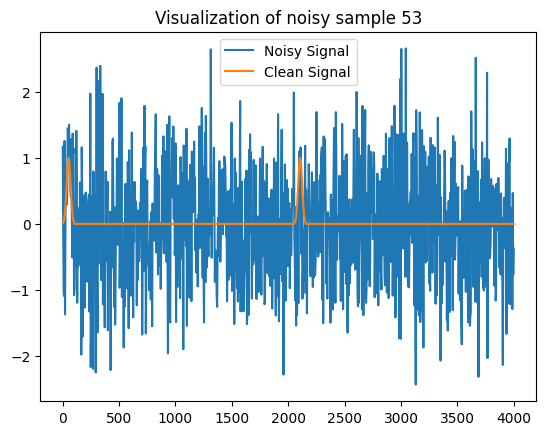

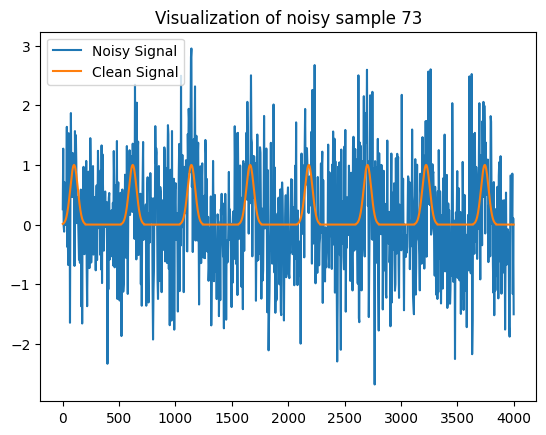

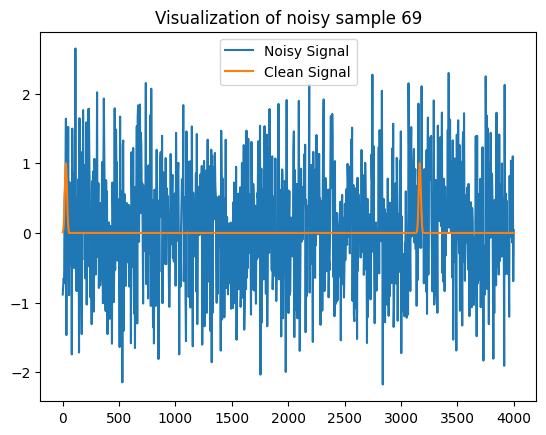

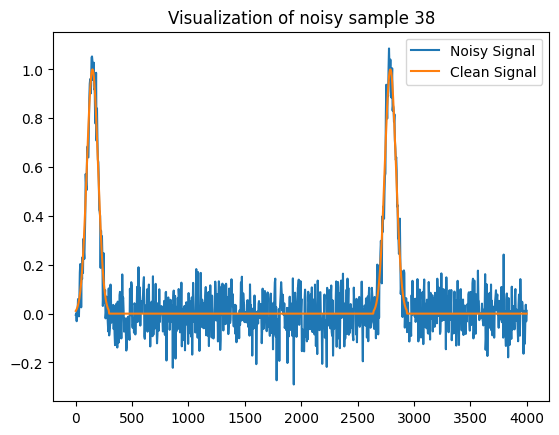

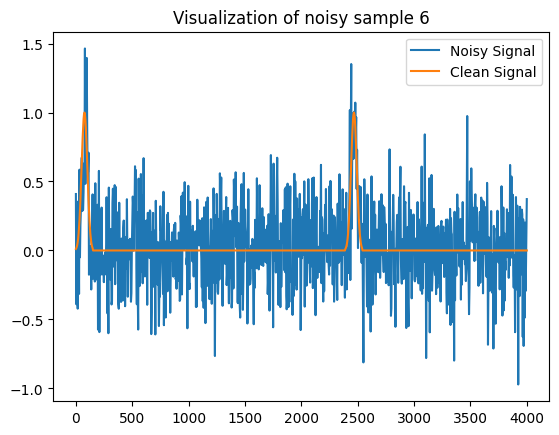

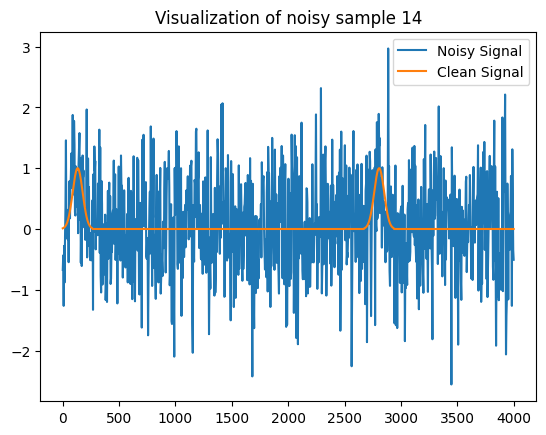

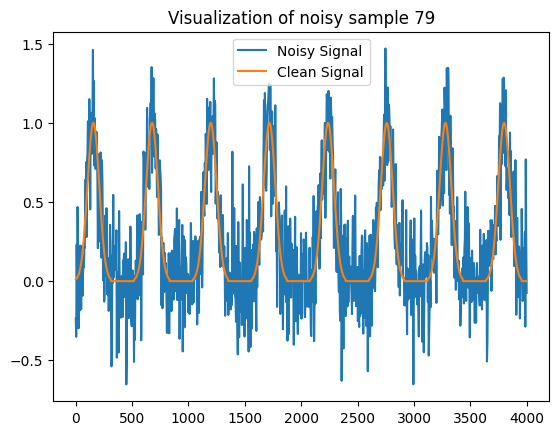

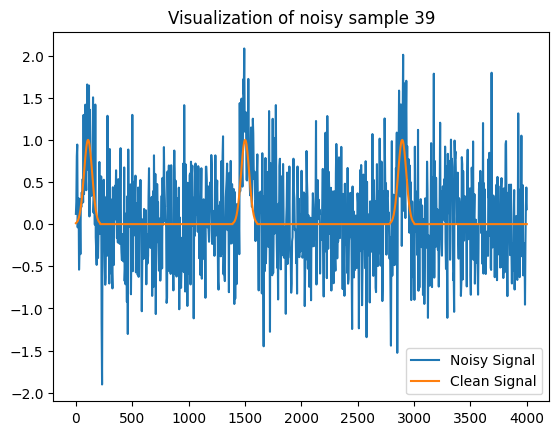

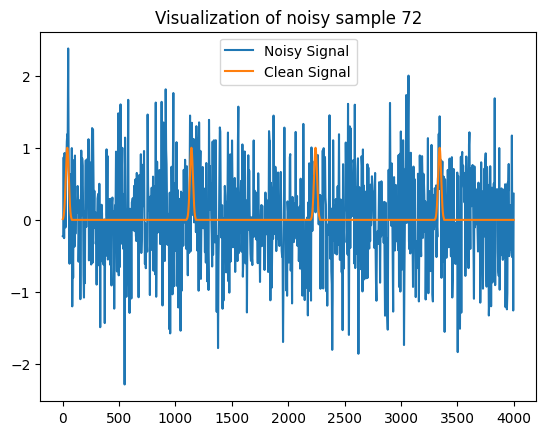

In [169]:

# Visualize a few random samples
for i in range(0, num_samples_visualize):
  random_index = np.random.randint(0, len(noisy_samples)-1)
  x_axis, y_axis = noisy_samples[random_index]
  x_axis2, y_axis2 = clean_samples[random_index]
  plt.plot(x_axis, y_axis, label = "Noisy Signal")
  plt.plot(x_axis2, y_axis2, label = "Clean Signal")
  plt.title(f'Visualization of noisy sample {random_index}')
  plt.legend()
  plt.show()

# Importing Packages

In [4]:
import tensorflow.keras
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import Conv1D, Conv1DTranspose
from tensorflow.keras.constraints import max_norm
import matplotlib.pyplot as plt
import numpy as np
import math

## Training and Testing LSTM Model

In [ ]:
# Load the noisy data
data_noisy = np.load('./signal_13_noisy.npy')
x_val_noisy, y_val_noisy = data_noisy[:,0], data_noisy[:,1]

# Load the pure data
data_pure = np.load('./signal_13.npy')
x_val_pure, y_val_pure = data_pure[:,0], data_pure[:,1]

sequence_length = 50
X = []
y = []
num_features = 1
num_samples = y_val_noisy.shape[0]

# Reshaping needs to fit the model
for i in range(num_samples):
    for j in range(0, y_val_noisy.shape[1] - sequence_length - 1, sequence_length):
        X.append(y_val_noisy[i, j:j + sequence_length].reshape(sequence_length, num_features))
        y.append(y_val_pure[i, j + 1:j + 1 + sequence_length].reshape(sequence_length, num_features))

X = np.array(X)
y = np.array(y)


# Define model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, 1)),
    LSTM(64, return_sequences=True),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))  # Output: one value per timestep
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

# Train the model
history = model.fit(X, y, epochs=15, batch_size=32, validation_split=0.1)

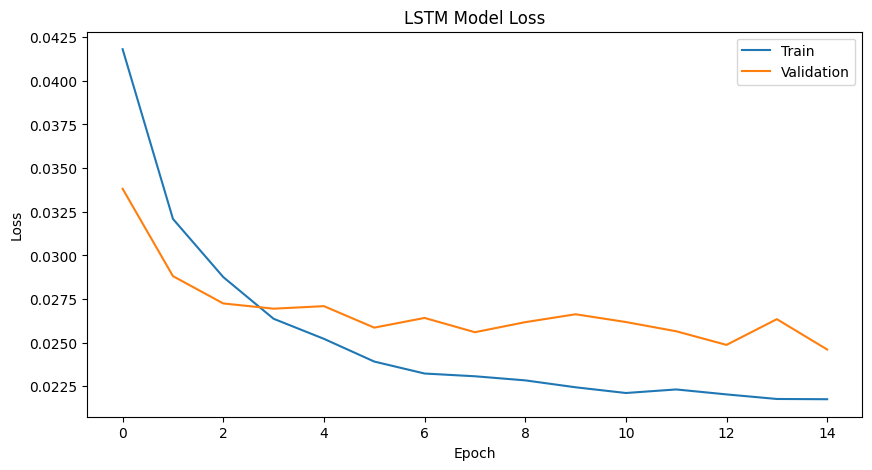

In [171]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

Test on real data

In [172]:
lstm_prediction = model.predict(noisy_ne)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


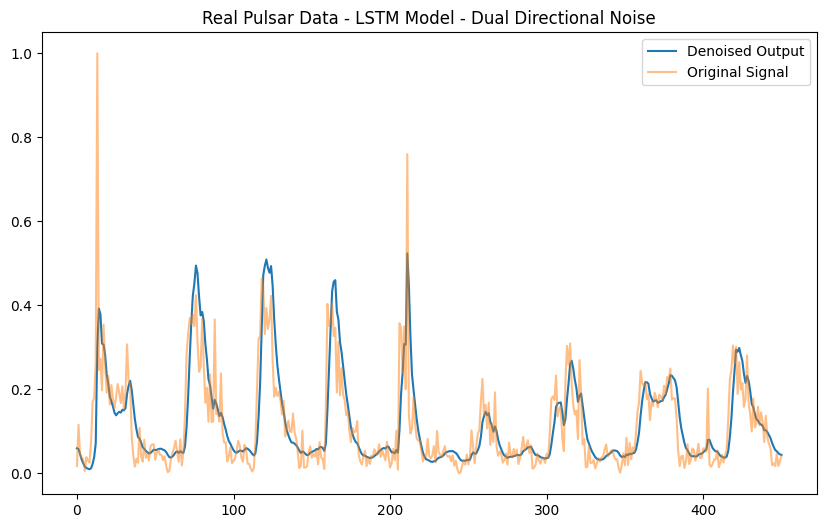

In [174]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(noisy_new_signal, label='Noisy Input')
plt.plot(lstm_prediction[0,:,0], label='Denoised Output')
plt.plot(siga, label = 'Original Signal', alpha = 0.5)
plt.legend()
plt.title("Real Pulsar Data - LSTM Model - Dual Directional Noise")
plt.show()

## Training and Testing Encoder Model

In [130]:

# Model configuration
input_shape = (150, 1)
batch_size = 150
no_epochs = 10
train_test_split = 0.3
validation_split = 0.2
verbosity = 1
max_norm_value = 2.0

# Load data
data_noisy = np.load('./signal_12_noisy.npy')
x_val_noisy, y_val_noisy = data_noisy[:,0], data_noisy[:,1]
data_pure = np.load('./signal_12.npy')
x_val_pure, y_val_pure = data_pure[:,0], data_pure[:,1]

# Reshape data
y_val_noisy_r = []
y_val_pure_r = []
for i in range(0, len(y_val_noisy)):
  noisy_sample = y_val_noisy[i]
  pure_sample = y_val_pure[i]
  noisy_sample = (noisy_sample - np.min(noisy_sample)) / (np.max(noisy_sample) - np.min(noisy_sample))
  pure_sample = (pure_sample - np.min(pure_sample)) / (np.max(pure_sample) - np.min(pure_sample))
  y_val_noisy_r.append(noisy_sample)
  y_val_pure_r.append(pure_sample)
y_val_noisy_r   = np.array(y_val_noisy_r)
y_val_pure_r    = np.array(y_val_pure_r)
noisy_input     = y_val_noisy_r.reshape((y_val_noisy_r.shape[0], y_val_noisy_r.shape[1], 1))
pure_input      = y_val_pure_r.reshape((y_val_pure_r.shape[0], y_val_pure_r.shape[1], 1))

# Train/test split
percentage_training = math.floor((1 - train_test_split) * len(noisy_input))
noisy_input, noisy_input_test = noisy_input[:percentage_training], noisy_input[percentage_training:]
pure_input, pure_input_test = pure_input[:percentage_training], pure_input[percentage_training:]


# Training the model

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 148, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 146, 32)        │        12,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_10             │ (None, 148, 32)        │         3,104 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_11             │ (None, 150, 128)       │        12,416 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 150, 1)         │           385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,737 (112.25 KB)

 Trainable params: 28,737 (112.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 0.4713 - val_loss: 0.2824
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - loss: 0.2779 - val_loss: 0.2193
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - loss: 0.2195 - val_loss: 0.1894
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - loss: 0.1977 - val_loss: 0.1813
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - loss: 0.1912 - val_loss: 0.1799
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - loss: 0.1886 - val_loss: 0.2059
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - loss: 0.2059 - val_loss: 0.1808
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - loss: 0.1908 - val_loss: 0.1762
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 0.1808 - val_loss: 0.1790
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - loss: 0.1924 - val_loss: 0.1810
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


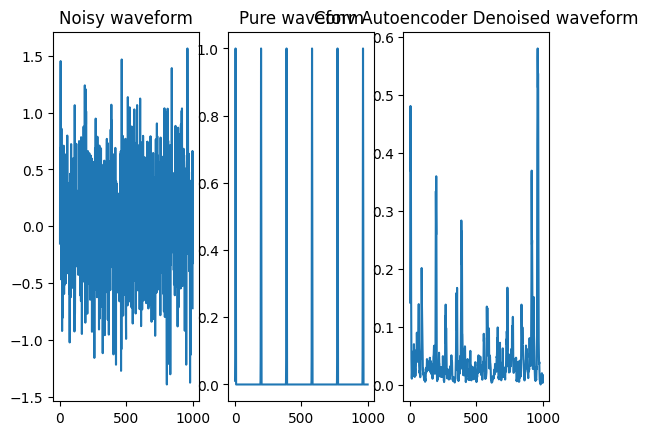

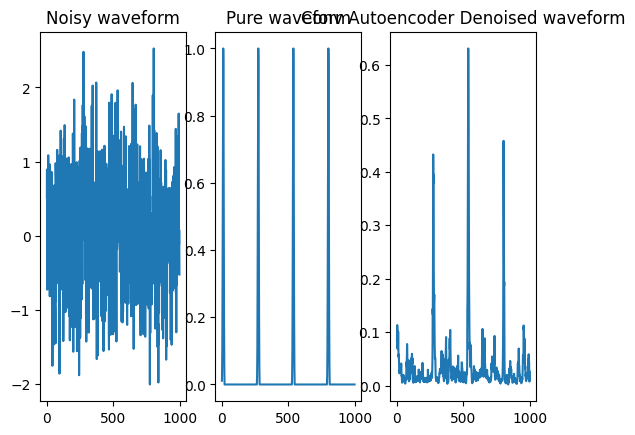

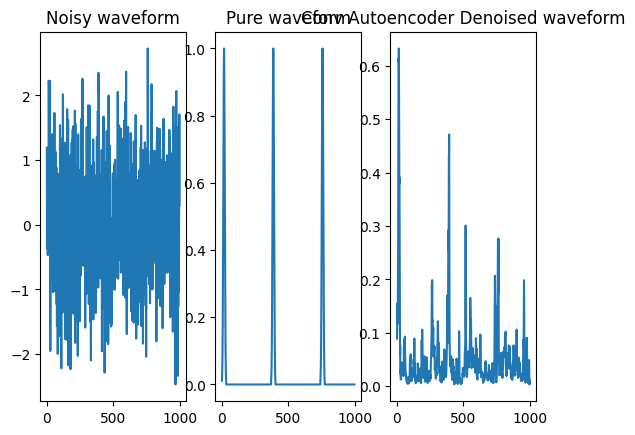

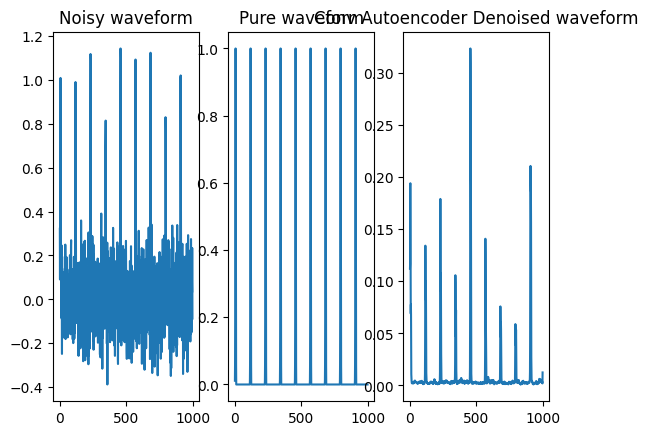

In [131]:
# Create the model
model = Sequential()
model.add(Conv1D(128, kernel_size=3, kernel_constraint=max_norm(max_norm_value), activation='relu', kernel_initializer='he_uniform', input_shape=input_shape))
model.add(Conv1D(32, kernel_size=3, kernel_constraint=max_norm(max_norm_value), activation='relu', kernel_initializer='he_uniform'))
model.add(Conv1DTranspose(32, kernel_size=3, kernel_constraint=max_norm(max_norm_value), activation='relu', kernel_initializer='he_uniform'))
model.add(Conv1DTranspose(128, kernel_size=3, kernel_constraint=max_norm(max_norm_value), activation='relu', kernel_initializer='he_uniform'))
model.add(Conv1D(1, kernel_size=3, kernel_constraint=max_norm(max_norm_value), activation='sigmoid', padding='same'))

model.summary()

# Compile and fit data
model.compile(optimizer='adam', loss='binary_crossentropy')
history = model.fit(noisy_input, pure_input,
                epochs=no_epochs,
                batch_size=batch_size,
                validation_split=validation_split)

# Generate reconstructions
num_reconstructions = 4
samples = noisy_input_test[:num_reconstructions]
reconstructions = model.predict(samples)

# Plot reconstructions
for i in np.arange(0, num_reconstructions):
  # Prediction index
  prediction_index = i + percentage_training
  # Get the sample and the reconstruction
  original = y_val_noisy[prediction_index]
  pure = y_val_pure[prediction_index]
  reconstruction = np.array(reconstructions[i])
  # Matplotlib preparations
  fig, axes = plt.subplots(1, 3)
  # Plot sample and reconstruciton
  axes[0].plot(original)
  axes[0].set_title('Noisy waveform')
  axes[1].plot(pure)
  axes[1].set_title('Pure waveform')
  axes[2].plot(reconstruction)
  axes[2].set_title('Conv Autoencoder Denoised waveform')
  plt.show()


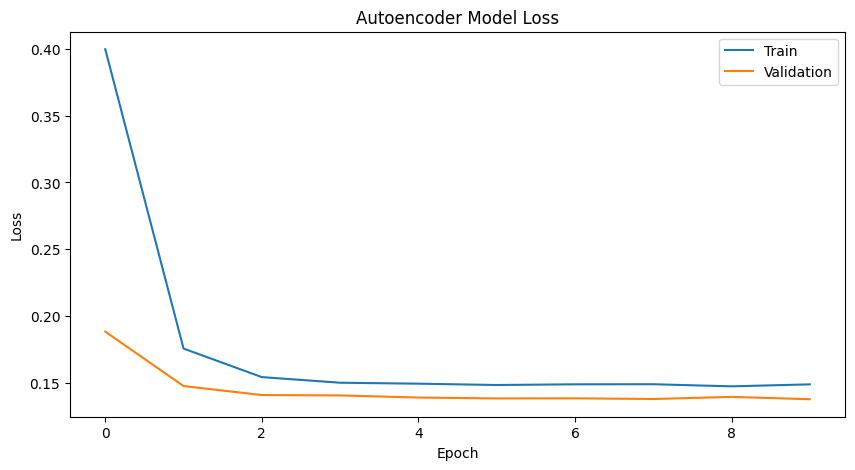

In [120]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Autoencoder Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# Visualizing more test-reconstructions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


<ipython-input-49-69dd99080d2e>:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


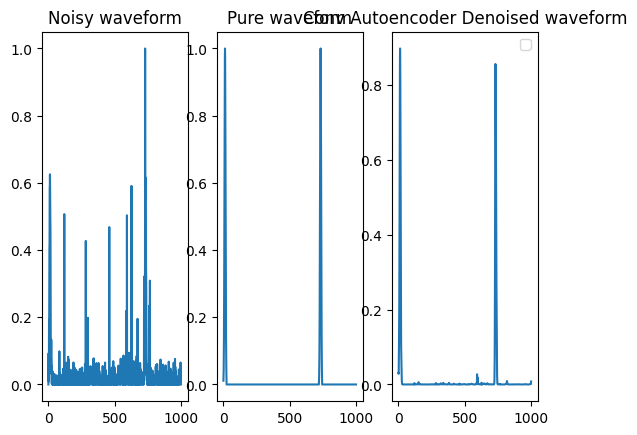

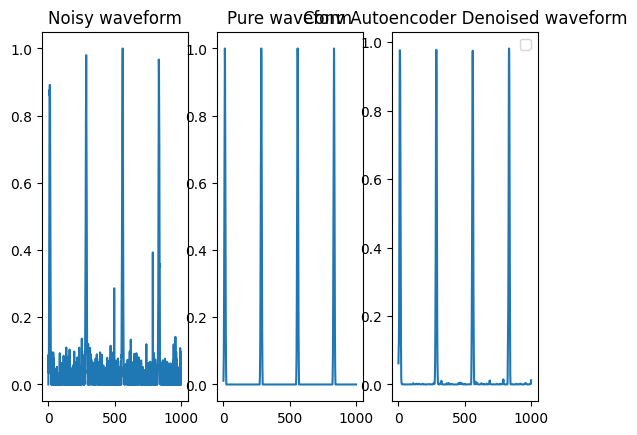

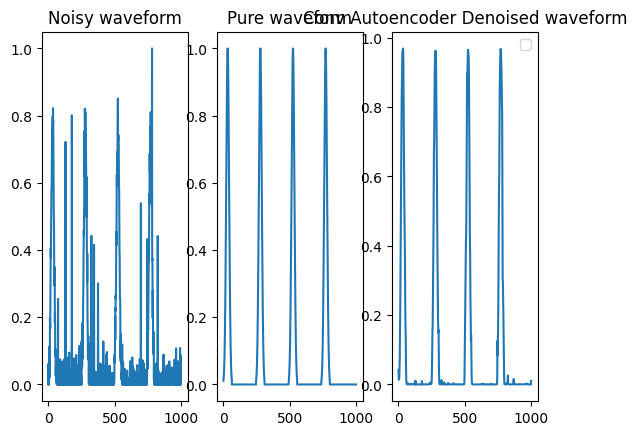

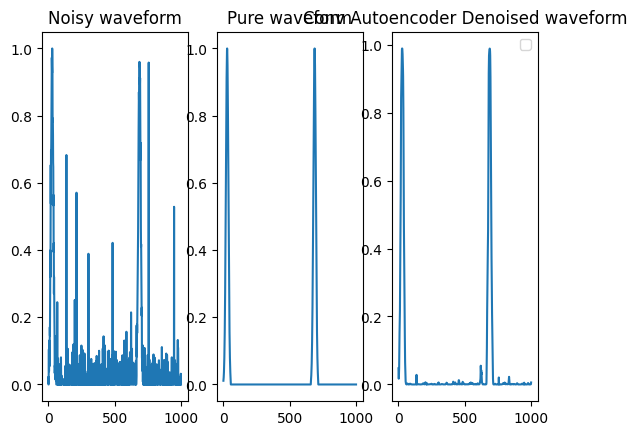

In [49]:
# Generate reconstructions
num_reconstructions = 4
samples = noisy_input_test[:num_reconstructions]
reconstructions = model.predict(samples)

# Plot reconstructions
for i in np.arange(0, num_reconstructions):
  # Prediction index
  prediction_index = i + percentage_training
  # Get the sample and the reconstruction
  original = y_val_noisy[prediction_index]
  pure = y_val_pure[prediction_index]
  reconstruction = np.array(reconstructions[i])
  # Matplotlib preparations
  fig, axes = plt.subplots(1, 3)
  # Plot sample and reconstruciton

  #plt.figure(figsize=(10, 6))
  #plt.plot(original, label = 'original')
  #plt.plot(pure, label = 'pure')
  #plt.plot(reconstruction, label = 'reconstruction')
  axes[0].plot(original)
  axes[0].set_title('Noisy waveform')
  axes[1].plot(pure)
  axes[1].set_title('Pure waveform')
  axes[2].plot(reconstruction)
  axes[2].set_title('Conv Autoencoder Denoised waveform')
  plt.legend()
  plt.show()


# Testing the model on a newly generated signal

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


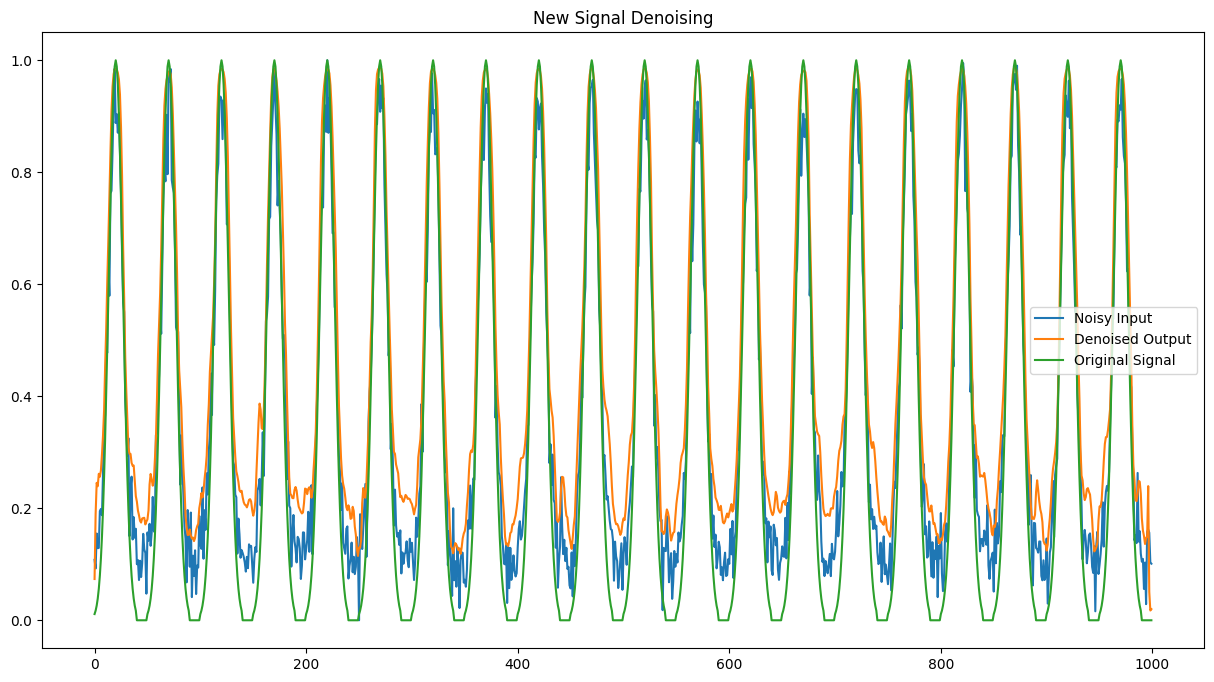

In [50]:
# Generate a new clean signal
new_signal = generate_clean_signal(num_bins=1000, period=50, pulse_width=20)

# Add noise to the new signal
noise_factor = 0.05
noise = np.random.normal(0, 1, new_signal.shape)
noisy_new_signal = new_signal + noise_factor * noise

# Normalize the new noisy signal (important for consistency with training data)
noisy_new_signal = (noisy_new_signal - np.min(noisy_new_signal)) / (np.max(noisy_new_signal) - np.min(noisy_new_signal))

# Reshape for model input
noisy_new_signal_reshaped = noisy_new_signal.reshape((1, noisy_new_signal.shape[0], 1))

# Predict with the model
new_reconstruction = model.predict(noisy_new_signal_reshaped)

# Plot the results
plt.figure(figsize=(15, 8))
plt.plot(noisy_new_signal, label='Noisy Input')
plt.plot(new_reconstruction[0,:,0], label='Denoised Output')
plt.plot(new_signal, label = 'Original Signal')
plt.legend()
plt.title("New Signal Denoising")
plt.show()


# Loading in new REAL data

All of the original data is stored in .FITS files, so we need to transfer the important aspects to a numpy array for analysis

In [51]:
#Imports!
from astropy.io import fits
from astropy.table import Table
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [52]:
hdul = fits.open('/content/drive/MyDrive/Pulsar/PH00.fits')  # Replace with your file path

In [53]:
# Import all the data from fits file to numpy array
data = hdul[1].data
table = Table(data)
names = [name for name in table.colnames if len(table[name].shape) <= 1]
newtable= table[names]
df_PH00 = newtable.to_pandas()
df_test = df_PH00

# Create an array of values from 0 to 96000 in steps of 1000
array = np.arange(0, 96001, 100).tolist()


In [54]:
constant_value = df_test["TIME"].min()
constant_value

441766820.579824

Must add a constant so that the time starts at the right location instead of at 0

In [55]:
def add_constant_to_list(original_list, constant):
  return [x + constant for x in original_list]

In [56]:
new_list = add_constant_to_list(array, constant_value)

In [57]:
binned_time = pd.cut(df_test["TIME"], bins=new_list, labels=False, include_lowest=True)
binned_df = df_test.groupby(binned_time)["ENERGY"].sum().reset_index()
binned_df.columns = ["TIME_BIN", "TOTAL_ENERGY"]

binned_df

,TIME_BIN,TOTAL_ENERGY
0,0.0,4814.395508
1,1.0,30873.046875
2,2.0,11747.054688
3,3.0,10050.825195
4,4.0,9105.930664
...,...,...
446,955.0,4743.148438
447,956.0,12617.880859
448,957.0,4825.375000
449,958.0,7913.601074


In [58]:
scaler = MinMaxScaler()

# Reshape  and normalize it
binned_df["TOTAL_ENERGY"] = scaler.fit_transform(binned_df["TOTAL_ENERGY"].values.reshape(-1, 1))


In [59]:
siga = binned_df["TOTAL_ENERGY"].to_numpy()

In [132]:
noisy_ne = siga.reshape((1, siga.shape[0], 1))
prediction = model.predict(noisy_ne)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


# Plotting REAL data with Autoencoder

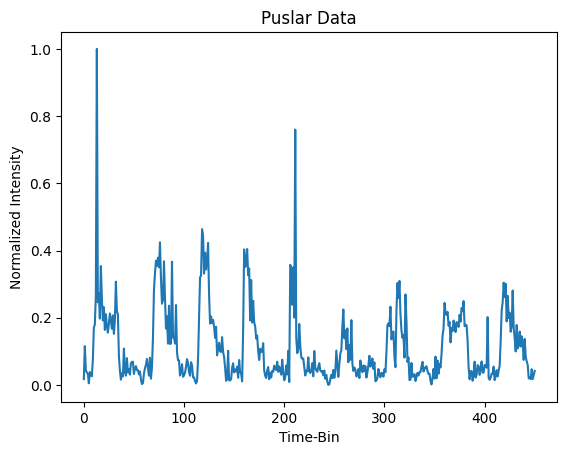

In [65]:
plt.plot(noisy_ne[0,:,0], label='Denoised Output') # Access the first sample and the first channel
plt.title("Puslar Data")
plt.xlabel("Time-Bin")
plt.ylabel("Normalized Intensity")
plt.show()

We have to normalize the predicted version, probably due to an error in how we normalized it to begin with.

In [134]:
predic = (prediction - np.min(prediction)) / (np.max(prediction) - np.min(prediction))

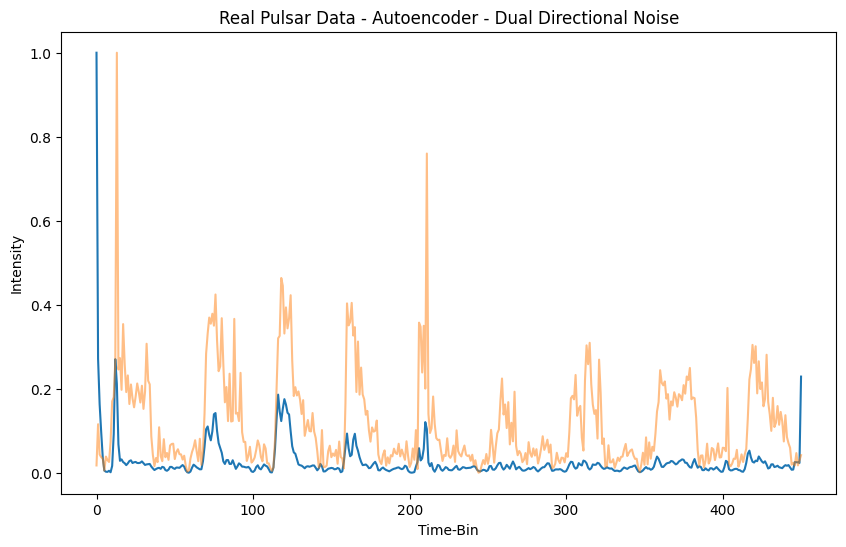

In [136]:
# Plot the results
plt.figure(figsize=(10, 6))
#plt.plot(noisy_new_signal, label='Noisy Input')
plt.plot(predic[0,:,0], label='Denoised Output') # Access the first sample and the first channel
plt.plot(siga, label = 'Original Signal', alpha = 0.5) #Plot the original signal
plt.xlabel("Time-Bin")
plt.ylabel("Intensity")
#plt.legend()
plt.title("Real Pulsar Data - Autoencoder - Dual Directional Noise")
plt.show()
